In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4.1-mini")

In [15]:
# Define the state structure for the workflow

class BatsManState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float # srtike rate
    bpb: float # balls per boundary
    boundary_percentage: float
    summary: str


In [31]:
def calculate_sr(state: BatsManState) -> BatsManState:

    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}


In [32]:
def calculate_bpb(state: BatsManState) -> BatsManState:

    bpb = (state['balls']/(state['fours'] + state['sixes']))
    
    return {'bpb': bpb}

In [33]:
def boundary_percentage(state: BatsManState) -> BatsManState:
    boundary_percentage = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    
    return {'boundary_percentage': boundary_percentage}

In [34]:
def summary(state: BatsManState) -> BatsManState:
    
    summary = f"""
        Strike Rate = {state['sr']} \n
        Balls Per Boundary = {state['bpb']} \n
        Boundary Percentage = {state['boundary_percentage']} \n
    
    """

    return {'summary': summary}
    

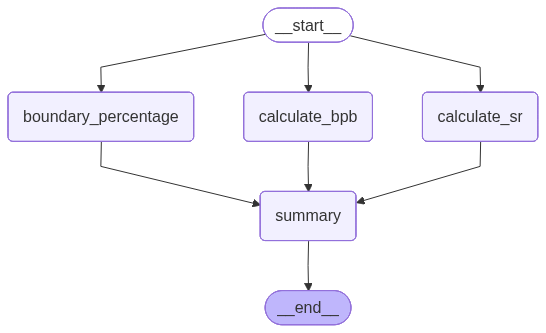

In [35]:
graph = StateGraph(BatsManState)

# add Node
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('boundary_percentage', boundary_percentage)
graph.add_node('summary', summary)

# add Edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'boundary_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('boundary_percentage', 'summary')

graph.add_edge('summary', END)


# compile graph
workflow = graph.compile()
workflow

In [36]:
initital_state = {
    'runs': 100,
    'balls': 50,
    'fours': 7,
    'sixes': 4
}

final_state = workflow.invoke(initital_state)

final_state

{'runs': 100,
 'balls': 50,
 'fours': 7,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 4.545454545454546,
 'boundary_percentage': 52.0,
 'summary': '\n        Strike Rate = 200.0 \n\n        Balls Per Boundary = 4.545454545454546 \n\n        Boundary Percentage = 52.0 \n\n\n    '}